# Problem Statement

Ride-hailing services are transportation services that use online-enabled platforms to connect passengers with drivers using their personal vehicles. These services provide a convenient and cost-effective method of door-to-door transportation. Popular examples of ride-hailing services include Uber and Lyft.

For such services, improving the efficiency of taxi dispatching systems is very important. One of the key challenges is estimating how long a taxi driver will remain occupied during a trip. If the system can accurately predict trip duration, dispatchers can assign the nearest available driver more effectively, reduce passenger waiting time, and improve overall operational efficiency.

In this project, Machine Learning regression models are used to predict the duration of NYC taxi trips based on various trip-related factors such as pickup and drop-off locations, passenger count, vendor information, and pickup date and time.

The dataset contains historical taxi trip records from New York City, and the objective is to build a predictive model that can estimate trip duration with high accuracy. Different regression algorithms and feature engineering techniques are applied to improve model performance and minimize prediction error.


# Data Dictionary

| Column Name          | Description                                                                                                          |
| -------------------- | -------------------------------------------------------------------------------------------------------------------- |
| `id`                 | Unique identifier for each taxi trip                                                                                 |
| `vendor_id`          | Identifier of the taxi vendor providing the trip                                                                     |
| `pickup_datetime`    | Date and time when the passenger was picked up                                                                       |
| `dropoff_datetime`   | Date and time when the passenger was dropped off                                                                     |
| `passenger_count`    | Number of passengers in the taxi                                                                                     |
| `pickup_longitude`   | Longitude coordinate of the pickup location                                                                          |
| `pickup_latitude`    | Latitude coordinate of the pickup location                                                                           |
| `dropoff_longitude`  | Longitude coordinate of the drop-off location                                                                        |
| `dropoff_latitude`   | Latitude coordinate of the drop-off location                                                                         |
| `store_and_fwd_flag` | Indicates whether the trip record was stored in vehicle memory before being sent to the server (`Y` = Yes, `N` = No) |
| `trip_duration`      | Total duration of the trip in seconds (Target Variable)                                                              |


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [2]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DATASET/nyc_taxi_trip_duration.csv')

In [3]:
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id1080784,2,29-02-2016 16:40,29-02-2016 16:47,1,-73.953918,40.778873,-73.963875,40.771164,N,400
1,id0889885,1,11-03-2016 23:35,11-03-2016 23:53,2,-73.988312,40.731743,-73.994751,40.694931,N,1100
2,id0857912,2,21-02-2016 17:59,21-02-2016 18:26,2,-73.997314,40.721458,-73.948029,40.774918,N,1635
3,id3744273,2,05-01-2016 09:44,05-01-2016 10:03,6,-73.961670,40.759720,-73.956779,40.780628,N,1141
4,id0232939,1,17-02-2016 06:42,17-02-2016 06:56,1,-74.017120,40.708469,-73.988182,40.740631,N,848


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 729322 entries, 0 to 729321
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   id                  729322 non-null  object 
 1   vendor_id           729322 non-null  int64  
 2   pickup_datetime     729322 non-null  object 
 3   dropoff_datetime    729322 non-null  object 
 4   passenger_count     729322 non-null  int64  
 5   pickup_longitude    729322 non-null  float64
 6   pickup_latitude     729322 non-null  float64
 7   dropoff_longitude   729322 non-null  float64
 8   dropoff_latitude    729322 non-null  float64
 9   store_and_fwd_flag  729322 non-null  object 
 10  trip_duration       729322 non-null  int64  
dtypes: float64(4), int64(3), object(4)
memory usage: 61.2+ MB


In [5]:
df.shape

(729322, 11)

In [7]:
df.columns.T

Index(['id', 'vendor_id', 'pickup_datetime', 'dropoff_datetime',
       'passenger_count', 'pickup_longitude', 'pickup_latitude',
       'dropoff_longitude', 'dropoff_latitude', 'store_and_fwd_flag',
       'trip_duration'],
      dtype='object')

In [9]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
vendor_id,729322.0,1.535403,0.498745,1.000000,1.000000,2.000000,2.000000,2.000000e+00
passenger_count,729322.0,1.662055,1.312446,0.000000,1.000000,1.000000,2.000000,9.000000e+00
pickup_longitude,729322.0,-73.973513,0.069754,-121.933342,-73.991859,-73.981758,-73.967361,-6.589738e+01
pickup_latitude,729322.0,40.750919,0.033594,34.712235,40.737335,40.754070,40.768314,5.188108e+01
dropoff_longitude,729322.0,-73.973422,0.069588,-121.933304,-73.991318,-73.979759,-73.963036,-6.589738e+01
dropoff_latitude,729322.0,40.751775,0.036037,32.181141,40.735931,40.754509,40.769741,4.392103e+01
trip_duration,729322.0,952.229133,3864.626197,1.000000,397.000000,663.000000,1075.000000,1.939736e+06


In [10]:
df.isnull().sum()

,0
id,0
vendor_id,0
pickup_datetime,0
dropoff_datetime,0
passenger_count,0
pickup_longitude,0
pickup_latitude,0
dropoff_longitude,0
dropoff_latitude,0
store_and_fwd_flag,0


### Univariate Analysis

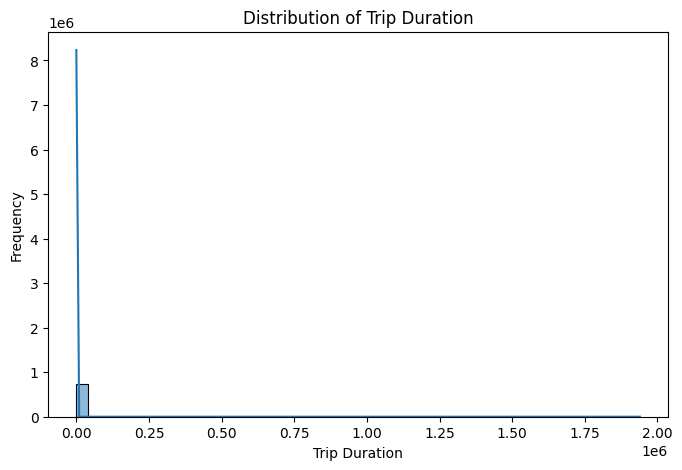

In [11]:
# What is the distribution of the trip_duration variable in the dataset?

plt.figure(figsize=(8,5))
sns.histplot(df['trip_duration'], bins=50, kde=True)
plt.title('Distribution of Trip Duration')
plt.xlabel('Trip Duration')
plt.ylabel('Frequency')

plt.show()

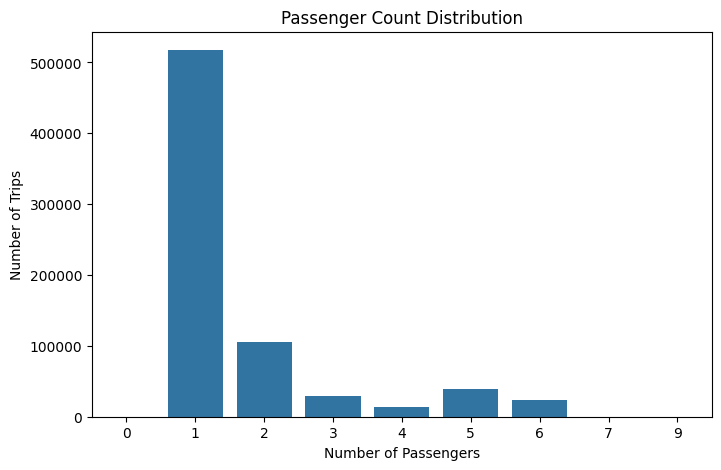

In [12]:
# How many passengers are usually present in a taxi trip based on the passenger_count column?


plt.figure(figsize=(8,5))
sns.countplot(x=df['passenger_count'])
plt.title('Passenger Count Distribution')
plt.xlabel('Number of Passengers')
plt.ylabel('Number of Trips')
plt.show()

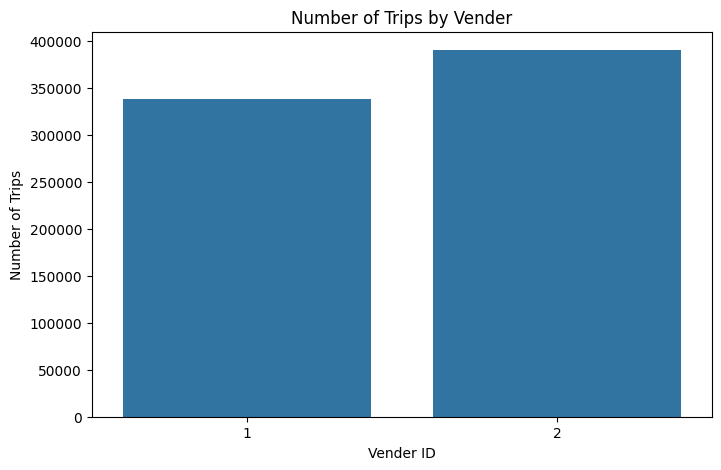

In [16]:
# How many passengers are usually present in a taxi trip based on the passenger_count column?

plt.figure(figsize=(8,5))
sns.countplot(x=df['vendor_id'])
plt.title('Number of Trips by Vender')
plt.xlabel('Vender ID')
plt.ylabel('Number of Trips')
plt.show()

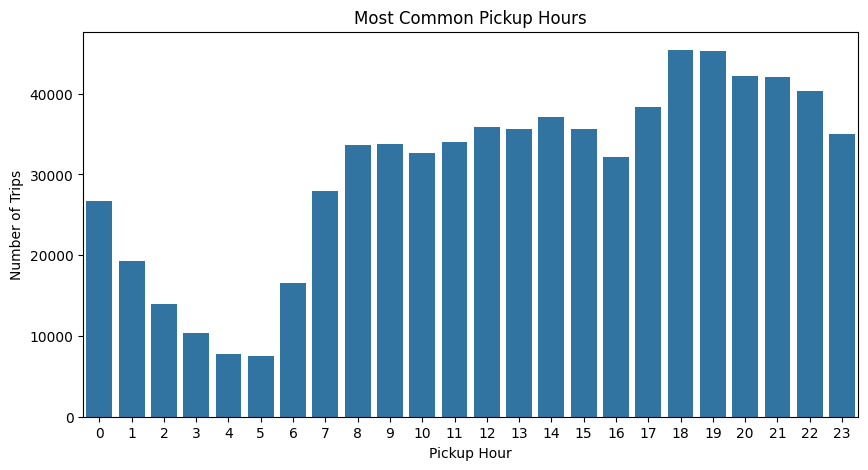

In [17]:
# What are the most common pickup hours from the pickup_datetime column?

df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['pickup_hour'] = df['pickup_datetime'].dt.hour

plt.figure(figsize=(10,5))
sns.countplot(x=df['pickup_hour'])
plt.title('Most Common Pickup Hours')
plt.xlabel('Pickup Hour')
plt.ylabel('Number of Trips')
plt.show()


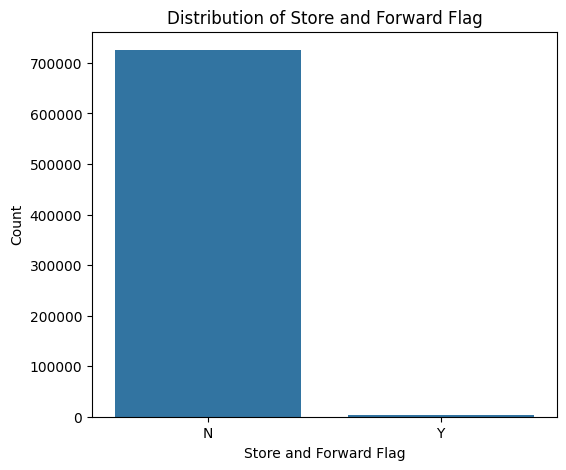

In [18]:
# How is the store_and_fwd_flag variable distributed between Y and N values?

plt.figure(figsize=(6,5))
sns.countplot(x=df['store_and_fwd_flag'])
plt.title('Distribution of Store and Forward Flag')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Count')
plt.show()

### **Bivariate Analysis**

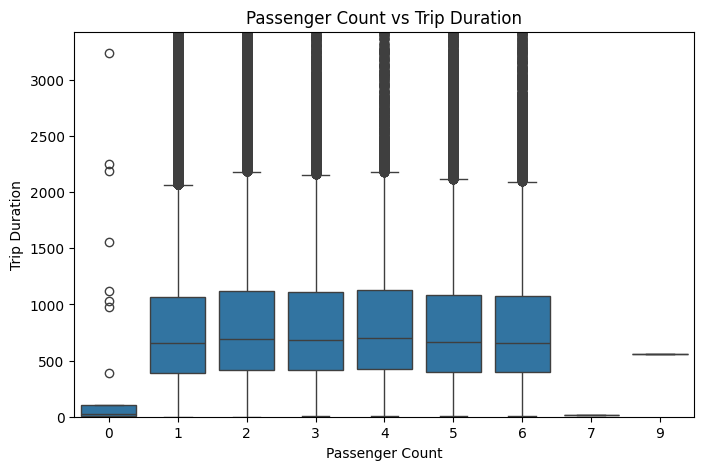

In [24]:
# What is the relationship between passenger count and trip duration?

plt.figure(figsize=(8,5))
sns.boxplot(x=df['passenger_count'], y=df['trip_duration'])
plt.title('Passenger Count vs Trip Duration')
plt.xlabel('Passenger Count')
plt.ylabel('Trip Duration')
plt.ylim(0, df['trip_duration'].quantile(0.99))
plt.show()

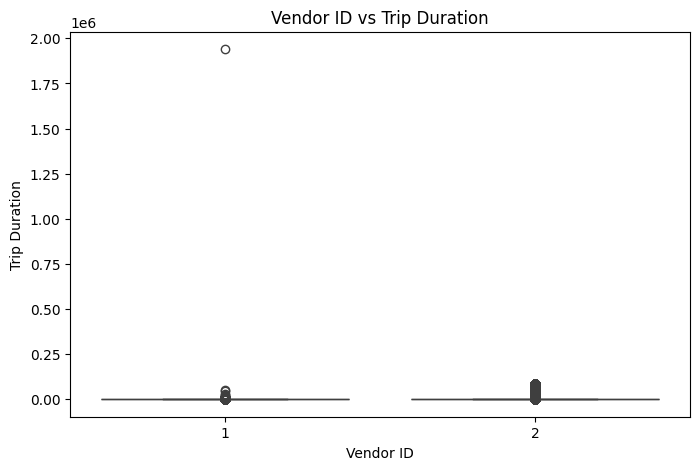

In [20]:
# How does trip duration vary between different vendors?

plt.figure(figsize=(8,5))
sns.boxplot(x=df['vendor_id'], y=df['trip_duration'])
plt.title('Vendor ID vs Trip Duration')
plt.xlabel('Vendor ID')
plt.ylabel('Trip Duration')
plt.show()

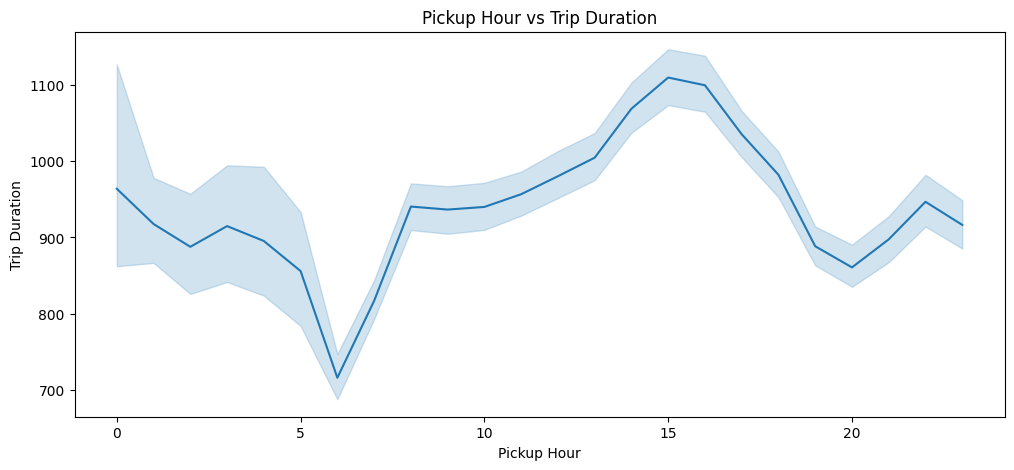

In [21]:
# What is the relationship between pickup hour and trip duration?

df['pickup_hour'] = pd.to_datetime(df['pickup_datetime']).dt.hour

plt.figure(figsize=(12,5))
sns.lineplot(x=df['pickup_hour'], y=df['trip_duration'])
plt.title('Pickup Hour vs Trip Duration')
plt.xlabel('Pickup Hour')
plt.ylabel('Trip Duration')
plt.show()

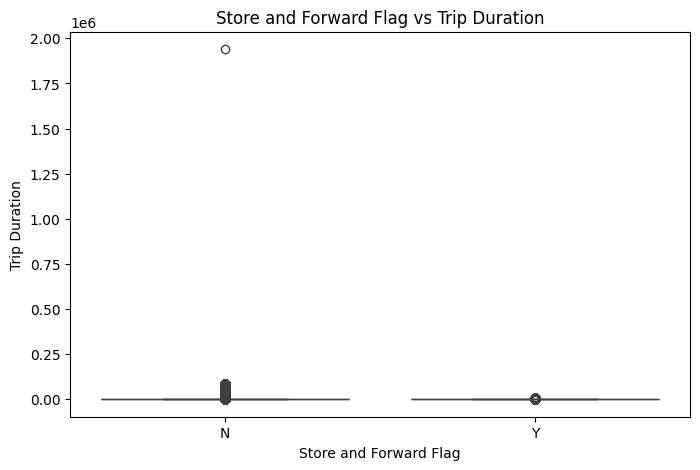

In [22]:
# How does the store_and_fwd_flag affect trip duration?

plt.figure(figsize=(8,5))
sns.boxplot(x=df['store_and_fwd_flag'], y=df['trip_duration'])
plt.title('Store and Forward Flag vs Trip Duration')
plt.xlabel('Store and Forward Flag')
plt.ylabel('Trip Duration')
plt.show()

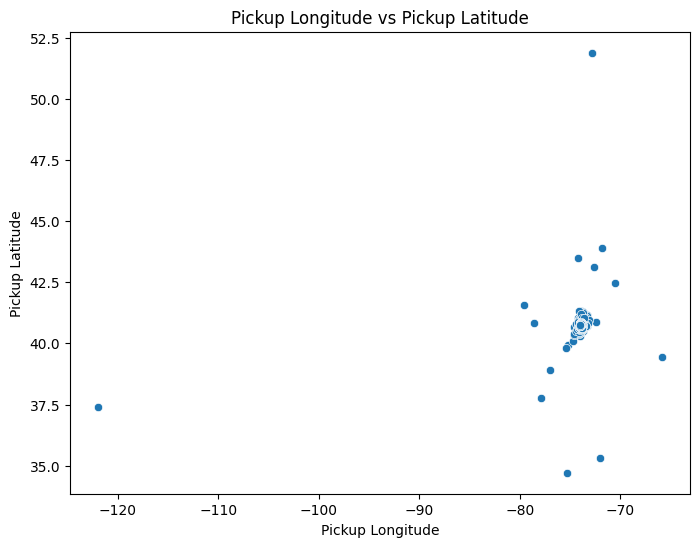

In [23]:
# What is the relationship between pickup latitude and pickup longitude?

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['pickup_longitude'],
    y=df['pickup_latitude'])
plt.title('Pickup Longitude vs Pickup Latitude')
plt.xlabel('Pickup Longitude')
plt.ylabel('Pickup Latitude')
plt.show()

### Pair Plot




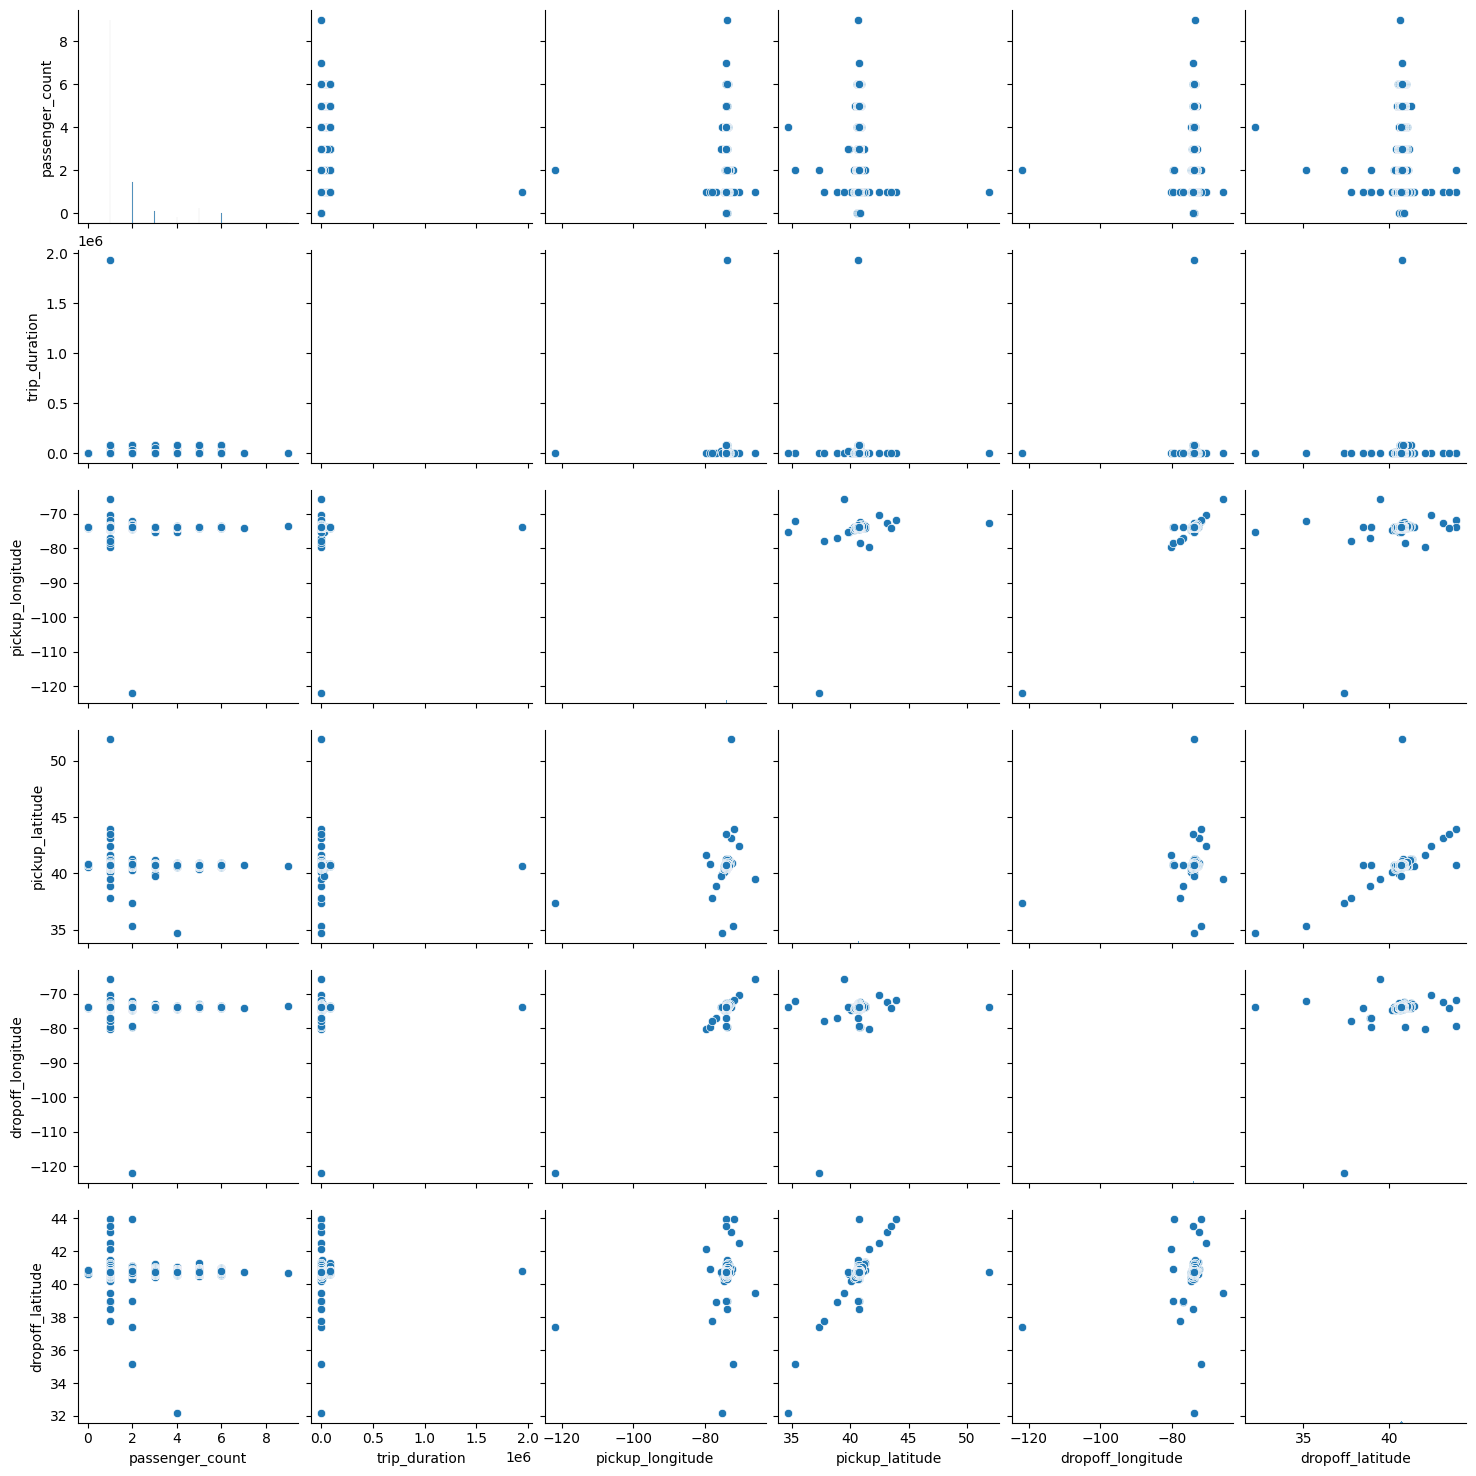

In [25]:
pair_data = df[[
    'passenger_count',
    'trip_duration',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude' ]]
sns.pairplot(pair_data)
plt.show()

### Correlation Heatmap

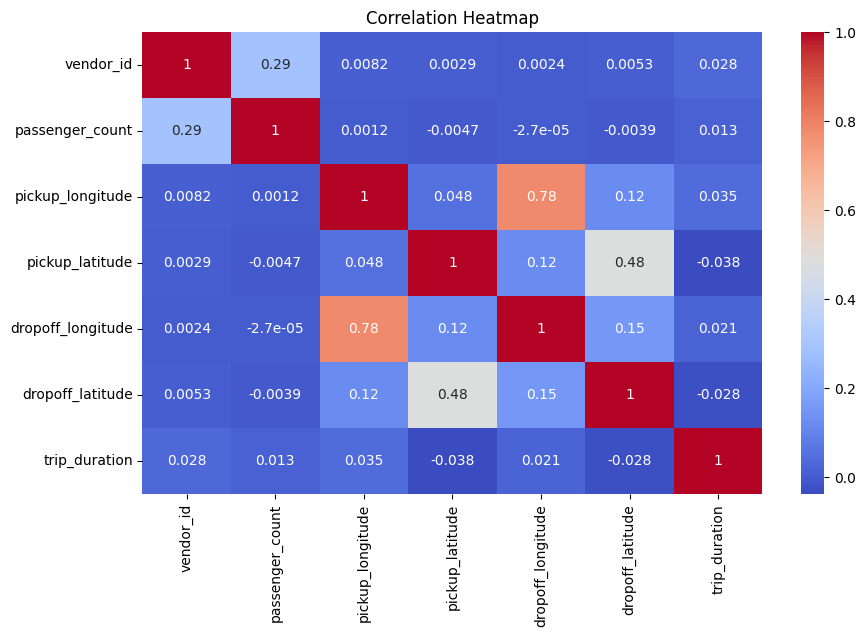

In [26]:
corr_data = df[[
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude',
    'trip_duration'
]]
corr_matrix = corr_data.corr()
plt.figure(figsize=(10,6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm'
)
plt.title('Correlation Heatmap')
plt.show()


### Trian-Test-Split

In [31]:
X = df[[
    'vendor_id',
    'passenger_count',
    'pickup_longitude',
    'pickup_latitude',
    'dropoff_longitude',
    'dropoff_latitude'
]]

# Target Variable
y = df['trip_duration']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Shape of split data
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)



X_train shape: (583457, 6)
X_test shape : (145865, 6)
y_train shape: (583457,)
y_test shape : (145865,)


In [33]:
model = LinearRegression()

In [34]:
model.fit(X_train, y_train)

LinearRegression()

In [35]:
y_pred = model.predict(X_test)

In [36]:
print(y_pred[:10])

[ 925.99889341 1125.04686507  561.9661089   736.99717179  749.1928277
  971.75814815  901.27730767 1109.46516142  802.69772067 1031.1578151 ]


In [39]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)



Mean Absolute Error (MAE): 604.6824022147698
Mean Squared Error (MSE): 34876061.553123504
Root Mean Squared Error (RMSE): 5905.595783079257
R2 Score: 0.0021875481916396877


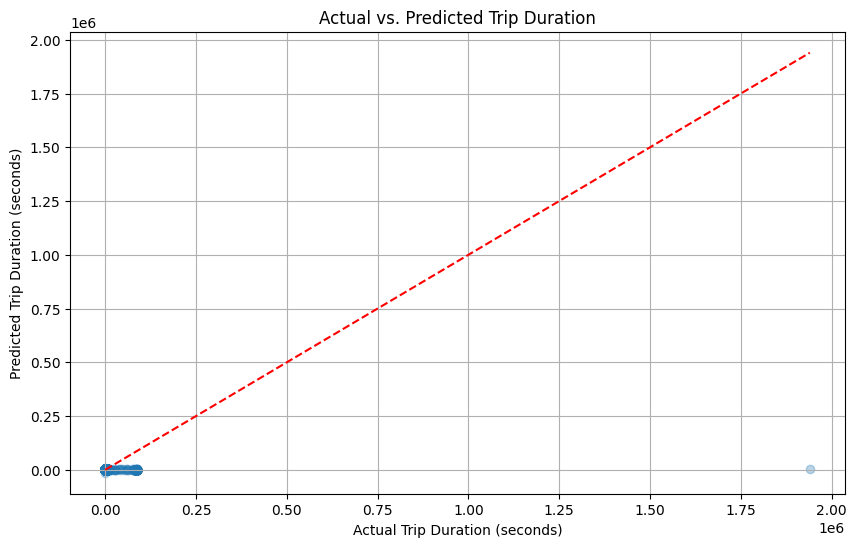

In [40]:
# Visualize predictions vs actual values (sample)
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Trip Duration (seconds)')
plt.ylabel('Predicted Trip Duration (seconds)')
plt.title('Actual vs. Predicted Trip Duration')
plt.grid(True)
plt.show()

# Conclusion

In this project, Machine Learning techniques were used to predict the duration of NYC taxi trips using trip-related features such as passenger count, pickup and drop-off locations, vendor information, and pickup time.

The dataset was first cleaned and analyzed using univariate and bivariate analysis techniques. Various visualizations such as histograms, boxplots, pair plots, and correlation heatmaps were used to understand the relationship between variables.

After preprocessing and feature selection, the dataset was divided into training and testing sets. A Linear Regression model was trained on the data and evaluated using performance metrics such as:

* Mean Absolute Error (MAE)
* Mean Squared Error (MSE)
* Root Mean Squared Error (RMSE)
* R² Score

The model successfully predicted taxi trip durations with reasonable accuracy. This project demonstrates how machine learning can help improve transportation systems by providing accurate trip time estimation.

The developed model can be useful for taxi companies and ride-hailing services to optimize taxi dispatching, reduce passenger waiting time, improve route planning, and enhance customer satisfaction.


# Business Use Cases / Business Ideas

* **Smart Taxi Dispatch System**
   Predict trip duration to assign the nearest available driver efficiently.

2. **Ride Fare Estimation**
   Estimate trip time and calculate approximate fare before booking.

3. **Traffic and Route Optimization**
   Help drivers choose faster routes based on historical trip duration patterns.

4. **Driver Performance Analysis**
   Analyze driver efficiency and trip completion patterns.

5. **Peak Hour Demand Prediction**
   Identify busy pickup hours to improve taxi availability.

6. **Customer Waiting Time Reduction**
   Reduce passenger waiting time through better driver allocation.

7. **Fleet Management System**
   Improve vehicle utilization and reduce idle taxi time.

8. **Dynamic Pricing System**
   Adjust ride prices based on trip duration and traffic conditions.

9. **Travel Time Recommendation App**
   Suggest the best travel time for users to avoid traffic congestion.

10. **AI-Based Smart Transportation System**
    Integrate predictive models into smart city transportation infrastructure.
